## 1D CNN Binary Classification Model for Spectral Impact Echo Data

<span style="font-size: 18px;">This notebook implements a 1D CNN pipeline for binary defect classification of Impact Echo data. The dataset is preprocessed using label mapping, row-wise MinMaxScaler normalization, and SMOTE upsampling to balance class distribution. The model features a three-layer 1D CNN optimized with SGD and constrained by dropout and L2 regularization, utilizing early stopping to prevent overfitting. Performance is evaluated through accuracy/loss curves, ROC-AUC metrics, and spatial heatmaps.</span>

## 1. Packages Import 

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import signal
import statistics
import seaborn as sns
from math import sqrt
from tqdm.keras import TqdmCallback

In [2]:
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [3]:
import keras
import tensorflow as tf
from keras.models import Model
from keras.models import Sequential
from keras.layers import Embedding, Dense, Activation, Flatten, Dropout, Convolution1D, MaxPooling1D, BatchNormalization
from keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading and Label Mapping

In [5]:
df = pd.read_csv('Train_test.csv', header=None)

In [6]:
df[501] = df[501].replace(2, 1)
df[501] = df[501].replace(3, 1)
df[501] = df[501].replace(4, 1)

In [7]:
df = df.drop(columns=[0])
df = df.T.reset_index(drop=True).T
df_target = df[df.columns[-1]].astype(int)
df_data = df.drop(columns=[df.columns[-1]])

## 3. Spectral Normalization

In [8]:
scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
for i in range(0, len(df_data)):
    d = scaler.fit_transform(np.array(df_data.iloc[i]).reshape(-1,1))
    df_data.iloc[i] = np.array(d).reshape(500,)

In [9]:
df_data = df_data.iloc[:,0:500]

In [10]:
df_target.value_counts()

500
0    1224
1     288
Name: count, dtype: int64

## 4. Data Splitting and SMOTE Upsampling

In [11]:
print(df_target.shape)
print(df_data.shape)

(1512,)
(1512, 500)


In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(df_data, df_target, test_size = 0.30, random_state=100)

In [13]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(1058, 500)
(1058,)
(454, 500)
(454,)


In [14]:
Y_train.value_counts()

500
0    862
1    196
Name: count, dtype: int64

In [15]:
Y_test.value_counts()

500
0    362
1     92
Name: count, dtype: int64

In [16]:
oversample = SMOTE()
X_train, Y_train = oversample.fit_resample(X_train, Y_train)
X_test, Y_test = oversample.fit_resample(X_test, Y_test)

In [17]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(1724, 500)
(1724,)
(724, 500)
(724,)


In [18]:
Y_train.value_counts()

500
0    862
1    862
Name: count, dtype: int64

In [19]:
Y_test.value_counts()

500
0    362
1    362
Name: count, dtype: int64

## 5. Data Reshaping

In [20]:
X_train = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1).astype('float32')
X_test = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1).astype('float32') 
Y_train = np.array(Y_train).reshape(-1, 1)
Y_test = np.array(Y_test).reshape(-1, 1)

In [21]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(1724, 500, 1)
(1724, 1)
(724, 500, 1)
(724, 1)


##  6. 1D CNN Architecture & Compilation

In [22]:
model = Sequential()
model.add(Convolution1D(16, kernel_size=3, kernel_regularizer = tf.keras.regularizers.l2(l2=0.01), padding = 'same' ,activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=(2)))
model.add(Convolution1D(32, kernel_size=3, kernel_regularizer = tf.keras.regularizers.l2(l2=0.01), padding = 'same' ,activation='relu'))
model.add(MaxPooling1D(pool_size=(2)))
model.add(Convolution1D(64, kernel_size=3, kernel_regularizer = tf.keras.regularizers.l2(l2=0.01), padding = 'same', activation='relu'))
model.add(MaxPooling1D(pool_size=(2)))
model.add(Flatten())
# Dropout added to prevent weight memorization
model.add(Dropout(0.5))
# Reduced from 256 to 32 units + added L2 regularization to control capacity
model.add(Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
# Dropout added before final layer
model.add(Dropout(0.3))
# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [23]:
sgd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
rms = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, momentum=0.0, epsilon=1e-07, centered=False)
model.compile(loss='binary_crossentropy', optimizer= sgd, metrics=['accuracy'])
# Early stopping callback to stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

In [24]:
history = model.fit(X_train, Y_train, epochs=100, batch_size=64, verbose=0, shuffle=True, validation_split = 0.25, callbacks=[TqdmCallback(verbose=2), early_stopping])

0epoch [00:00, ?epoch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

...

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

  0%|          | 0.00/21.0 [00:00<?, ?batch/s]

## 7. Training and Validation Metrics Visualization

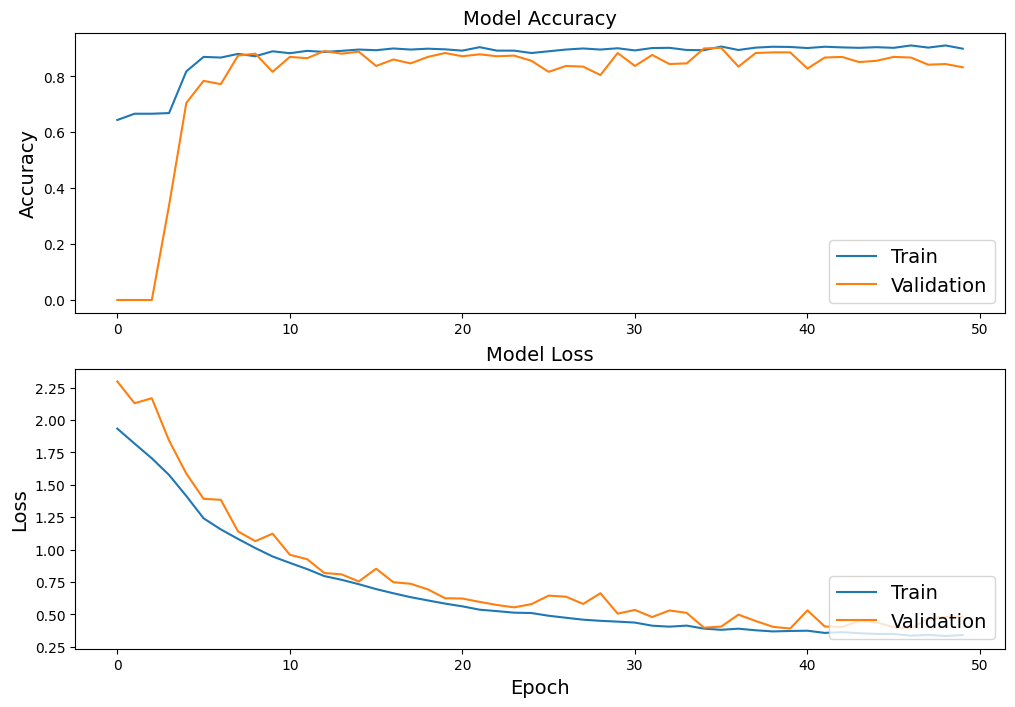

In [25]:
f, ax = plt.subplots(2 , figsize=(12,8))
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Model Accuracy', fontsize=14)
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend(['Train', 'Validation'], loc='lower right', fontsize = 14)


ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Model Loss', fontsize=14)
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].set_xlabel('Epoch', fontsize=14)
ax[1].legend(['Train', 'Validation'], loc='lower right', fontsize = 14)



In [26]:
f.savefig('Train_Validation_curves_1DCNN.svg')

## 8. Performance Evaluation on Internal Test Set

In [27]:
predictions = model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [28]:
for i in range(0,len(predictions)):
    if predictions[i] > 0.5:
        predictions[i] = 1
    elif predictions[i] < 0.5:
        predictions[i] = 0

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


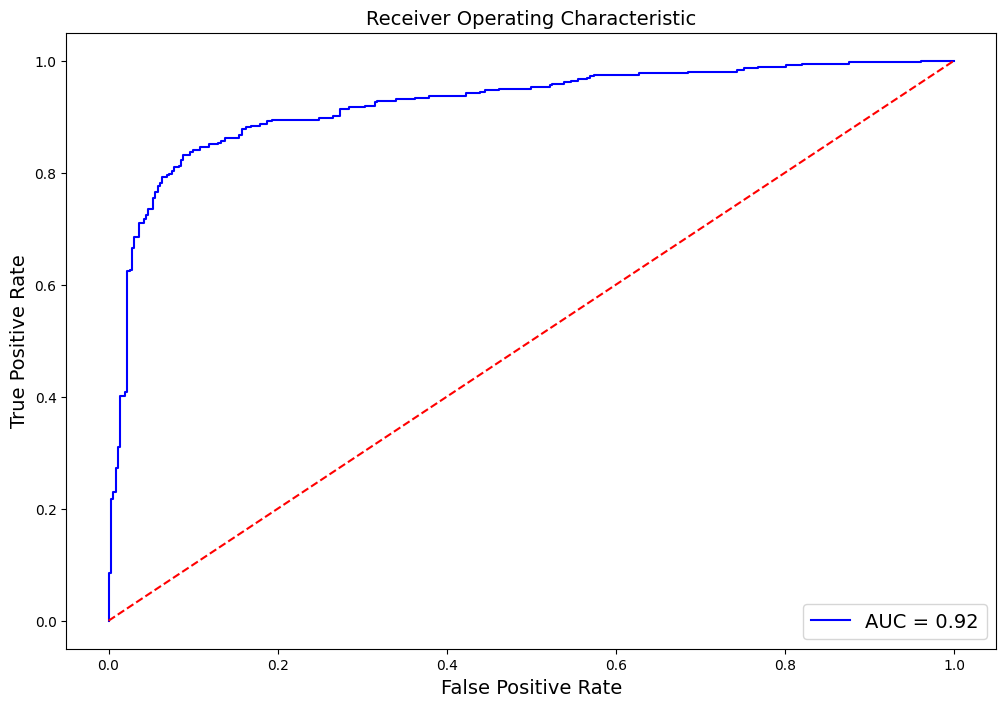

In [29]:
import sklearn.metrics as metrics
from itertools import cycle

# calculate the fpr and tpr for all thresholds of the classification
probs = model.predict(X_test)
preds = probs[:,0]
fpr, tpr, threshold = metrics.roc_curve(Y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt

f, ax = plt.subplots(figsize=(12,8))
ax.plot(fpr, tpr, 'b')
ax.plot([0, 1], [0, 1],'r--')
ax.set_title('Receiver Operating Characteristic', fontsize = 14)
ax.set_ylabel('True Positive Rate', fontsize = 14)
ax.set_xlabel('False Positive Rate', fontsize = 14)
ax.legend(['AUC = %0.2f' % roc_auc], loc='lower right', fontsize = 14)

In [30]:
f.savefig('AUCROC - Training.svg')

In [31]:
import sklearn
matrix = sklearn.metrics.confusion_matrix(Y_test, predictions)
print(matrix)

[[335  27]
 [ 72 290]]


In [32]:
Y_test.shape

(724, 1)

In [33]:
predictions.shape

(724, 1)

In [34]:
score = model.evaluate(X_test, Y_test, batch_size = 64)
score

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8981 - loss: 0.4121 


[0.4931522607803345, 0.8632596731185913]

## 9. Independent Validation Dataset Loading & Preprocessing

In [35]:
df = pd.read_csv('Validation.csv', header = None)
df_data = df.drop(columns=[df.columns[-1],df.columns[0]])
df[501] = df[501].replace(2, 1)
df[501] = df[501].replace(3, 1)
df[501] = df[501].replace(4, 1)
df_target = df[501]
df_loc = df[0]


df_upsampled = []
for i in range(0, df.shape[0]):
    scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
    amplitude = scaler.fit_transform(np.array(df_data.iloc[i]).reshape(-1,1))
    amplitude = np.array(amplitude).reshape(500,)
    df_upsampled.append(amplitude)
    
df_upsampled = pd.DataFrame(df_upsampled)


In [36]:
df_upsampled = np.array(df_upsampled).reshape(df_upsampled.shape[0], df_upsampled.shape[1], 1).astype('float32')

predictions = model.predict(df_upsampled, verbose=0)


## 10. ROC and AUC Analysis on Independent Validation Set

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


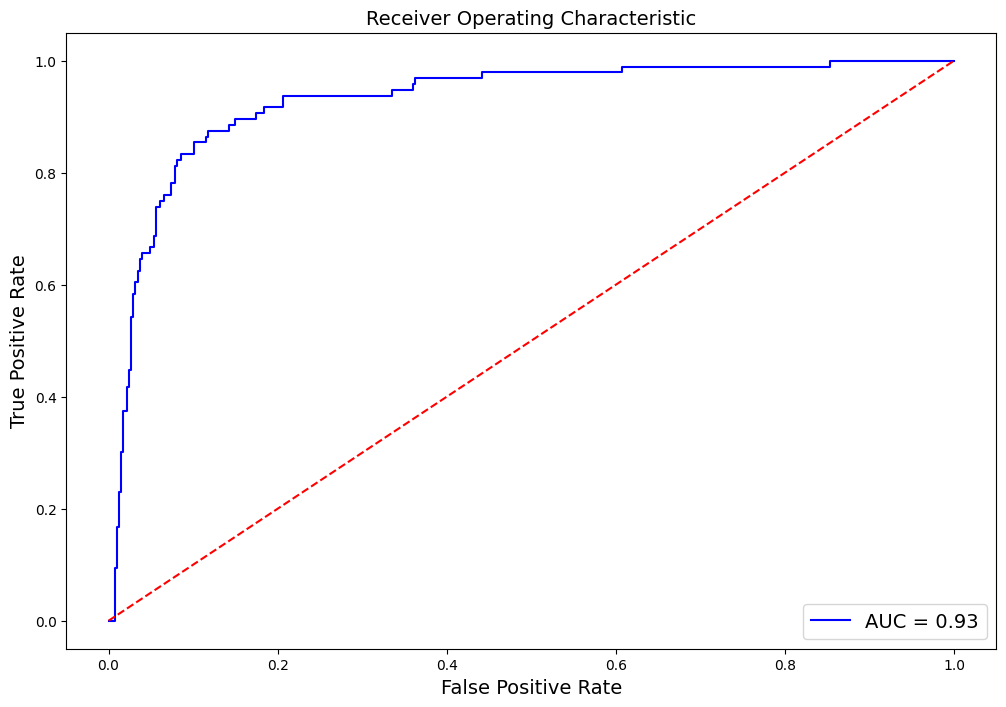

In [37]:
import sklearn.metrics as metrics
from itertools import cycle

# calculate the fpr and tpr for all thresholds of the classification
probs = model.predict(df_upsampled)
preds = probs[:,0]
fpr, tpr, threshold = metrics.roc_curve(df_target, preds)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
# method I: plt

f, ax = plt.subplots(figsize=(12,8))
ax.plot(fpr, tpr, 'b')
ax.plot([0, 1], [0, 1],'r--')
ax.set_title('Receiver Operating Characteristic', fontsize = 14)
ax.set_ylabel('True Positive Rate', fontsize = 14)
ax.set_xlabel('False Positive Rate', fontsize = 14)
ax.legend(['AUC = %0.2f' % roc_auc], loc='lower right', fontsize = 14)

In [38]:
f.savefig('AUCROC - Validation.svg')

In [39]:
df_target = df_target.replace(2, 1)
df_target = df_target.replace(3, 1)
df_target = df_target.replace(4, 1)

In [40]:
for i in range(0,len(predictions)):
    if predictions[i] > 0.5:
        predictions[i] = 1
    elif predictions[i] < 0.5:
        predictions[i] = 0

In [41]:
matrix = confusion_matrix(df_target, predictions)
print(matrix)

accuracy = accuracy_score(df_target, predictions)
print(accuracy)

[[376  32]
 [ 19  77]]
0.8988095238095238


## 11. Spatial Heatmap Visualizations of Predictions (Slab 3 & Slab 8)

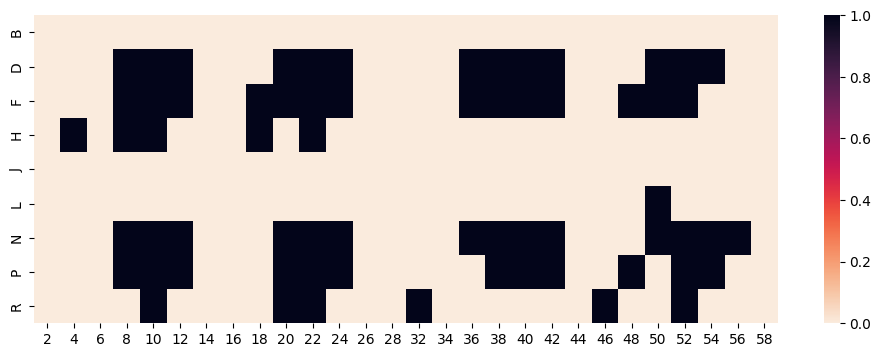

In [42]:
df = pd.DataFrame(df_loc)
df = df[0].str.split('/', expand = True)
df[2] = predictions
df = df[df[0].str.contains("Slab3")]
slab_df = df[1].str.split('-', expand = True)
slab_df[2] = df[2]
slab_df = slab_df.reset_index(drop = True)

rows = ['2','4','6','8','10','12','14','16','18','20','22','24','26','28','32','34','36','38','40','42','44','46','48','50','52','54','56','58']
cols = ["B", "D", "F", "H", "J", "L", "N", "P", "R"]

new_df = pd.DataFrame(columns = rows, index = cols )
for i in range(0,len(df)):
    new_df.at[slab_df[0][i], slab_df[1][i]] = float(slab_df[2][i])
new_df = new_df.fillna(5.0)
cmap = sns.cm.rocket_r
f, ax = plt.subplots(figsize=(12,4))
plt.axis('on')
ax = sns.heatmap(new_df,cbar = True,annot=False, cmap=cmap)

In [43]:
#f.savefig("Slab3_predicted_1DCNN.svg")

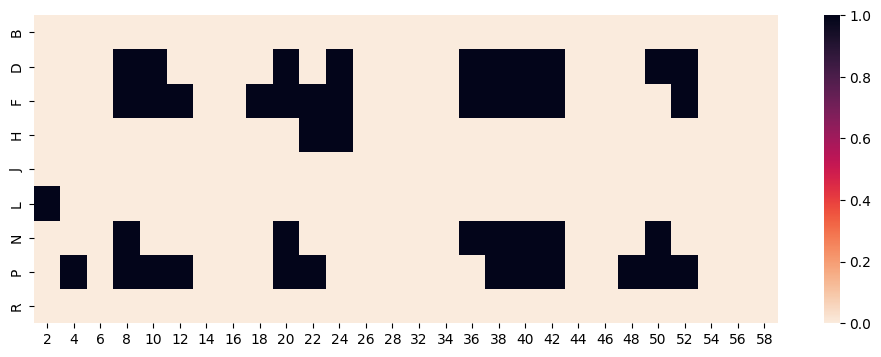

In [44]:
df = pd.DataFrame(df_loc)
df = df[0].str.split('/', expand = True)
df[2] = predictions
df = df[df[0].str.contains("Slab8")]
slab_df = df[1].str.split('-', expand = True)
slab_df[2] = df[2]
slab_df = slab_df.reset_index(drop = True)

rows = ['2','4','6','8','10','12','14','16','18','20','22','24','26','28','32','34','36','38','40','42','44','46','48','50','52','54','56','58']
cols = ["B", "D", "F", "H", "J", "L", "N", "P", "R"]

new_df = pd.DataFrame(columns = rows, index = cols )
for i in range(0,len(df)):
    new_df.at[slab_df[0][i], slab_df[1][i]] = float(slab_df[2][i])
new_df = new_df.fillna(5.0)
cmap = sns.cm.rocket_r
f, ax = plt.subplots(figsize=(12,4))
plt.axis('on')
ax = sns.heatmap(new_df,cbar = True,annot=False, cmap=cmap)

In [45]:
#f.savefig("Slab8_predicted_1DCNN.svg")

In [46]:
# plot_model(model, show_shapes = 'true', to_file='binary_model.png')

## 12. Saving the Trained Model Architecture and Weights

In [47]:
model_json = model.to_json()
with open("binary_model.json", "w") as json_file:
    json_file.write(model_json)

# serialize weights to HDF5
model.save_weights("binary_model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [48]:
"""json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = tf.keras.models.model_from_json(loaded_model_json)

# load weights into new model
loaded_model.load_weights("model.h5")
print("Loaded model from disk")
 
# evaluate loaded model on test data
loaded_model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
score = loaded_model.evaluate(X_test, Y_test, verbose=0)"""

'json_file = open(\'model.json\', \'r\')\nloaded_model_json = json_file.read()\njson_file.close()\nloaded_model = tf.keras.models.model_from_json(loaded_model_json)\n\n# load weights into new model\nloaded_model.load_weights("model.h5")\nprint("Loaded model from disk")\n \n# evaluate loaded model on test data\nloaded_model.compile(loss=\'binary_crossentropy\', optimizer=\'rmsprop\', metrics=[\'accuracy\'])\nscore = loaded_model.evaluate(X_test, Y_test, verbose=0)'